<a href="https://colab.research.google.com/github/AndrewHung87/startup_funding_analysis/blob/main/startup_funding_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Startup Funding Analysis
**Data Source:** Crunchbase Startup Dataset (1,827 records)  
**Objective:** Clean and explore startup data to uncover funding trends, industry distribution, and growth patterns.

**Tools:** Python, Pandas, Matplotlib, Seaborn

## Table of Contents
1. [Initial Data Exploration](#step-1)
2. [Data Cleaning](#step-2)
3. [Exploratory Data Analysis](#step-3)
4. [Key Insights](#step-4)

## Step 1: Initial Data Exploration
Get a first look at the data structure, sample records, and basic statistics.

In [1]:
import pandas as pd

# Load dataset
url = 'https://raw.githubusercontent.com/AndrewHung87/startup-funding-analysis/refs/heads/main/Startup_Data__Startup.csv'
df = pd.read_csv(url)
# Basic overview
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

Shape: (1827, 34)

Data Types:
Organization_Name                    object
Organization_Name_URL                object
Founded_Date                         object
Founders                             object
Number_of_Employees                  object
Description                          object
Industries                           object
Industry_Groups                      object
Headquarters_Location                object
Headquarters_Regions                 object
Postal_Code                          object
Diversity_Spotlight                  object
Estimated_Revenue_Range              object
Operating_Status                     object
Funding_Status                       object
Number_of_Funding_Rounds              int64
Last_Funding_Amount                  object
Last_Funding_Amount_Currency         object
Last_Funding_Date                    object
Last_Funding_Type                    object
Total_Funding_Amount                 object
Total_Funding_Amount_Currency        object
N

## Step 2: Data Cleaning

### 2.1 Missing Values Analysis
Before cleaning, we first identify which columns have missing values and how severe they are.

In [2]:
# Calculate missing values count and percentage
missing_count = df.isnull().sum()
missing_pct = df.isnull().sum() / len(df) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

# Show only columns that have missing values
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
Last_Layoff_Mention_Date,1823,99.78
Diversity_Spotlight,1735,94.96
Last_Leadership_Hiring_Date,1641,89.82
Estimated_Revenue_Range,1546,84.62
Additional_Comment,1529,83.69
Job_postings_on_official_website,1153,63.11
Postal_Code,772,42.26
Number_of_Lead_Investors,663,36.29
Founders,561,30.71
Top_5_Investors,407,22.28


### 2.2 Dropping Columns
Remove columns that are too sparse or unreliable to be useful in analysis.

In [3]:
# Columns to drop: too many missing values, unreliable data, or redundant
cols_to_drop = [
    'Last_Layoff_Mention_Date',       # 99.78% missing
    'Diversity_Spotlight',             # 94.96% missing
    'Last_Leadership_Hiring_Date',     # 89.82% missing
    'Additional_Comment',              # 83.69% missing, unstructured free text
    'Estimated_Revenue_Range',         # 84.62% missing
    'Postal_Code',                     # 42.26% missing, using Headquarters_Regions instead
    'Job_Postings_on_Linkedin',        # unreliable data collection method
    'Job_postings_on_official_website' # unreliable data collection method
]

df.drop(columns=cols_to_drop, inplace=True)

print(f"Remaining columns: {df.shape[1]}")
print(df.columns.tolist())

Remaining columns: 26
['Organization_Name', 'Organization_Name_URL', 'Founded_Date', 'Founders', 'Number_of_Employees', 'Description', 'Industries', 'Industry_Groups', 'Headquarters_Location', 'Headquarters_Regions', 'Operating_Status', 'Funding_Status', 'Number_of_Funding_Rounds', 'Last_Funding_Amount', 'Last_Funding_Amount_Currency', 'Last_Funding_Date', 'Last_Funding_Type', 'Total_Funding_Amount', 'Total_Funding_Amount_Currency', 'Number_of_Lead_Investors', 'Top_5_Investors', 'Trend_Score_7_Days', 'Trend_Score_30_Days', 'Trend_Score_90_Days', 'Growth_Trend', 'Active_Hiring']


### 2.3 Filling Missing Values
Apply targeted imputation strategies based on each column's context.

In [4]:
# --- Funding Amounts ---
# Fill Total_Funding_Amount with Last_Funding_Amount as a conservative estimate
df['Total_Funding_Amount'] = df['Total_Funding_Amount'].fillna(df['Last_Funding_Amount'])

# Fill remaining Last_Funding_Amount with 0 (no recent funding recorded)
df['Last_Funding_Amount'] = df['Last_Funding_Amount'].fillna(0)
df['Total_Funding_Amount'] = df['Total_Funding_Amount'].fillna(0)

# --- Currency ---
# Assume USD for missing currency fields (dataset is primarily US-based)
df['Last_Funding_Amount_Currency'] = df['Last_Funding_Amount_Currency'].fillna('USD')
df['Total_Funding_Amount_Currency'] = df['Total_Funding_Amount_Currency'].fillna('USD')

# --- Categorical Columns ---
# Fill with 'Unknown' to preserve row and flag missing data explicitly
cols_fill_unknown = [
    'Industries',
    'Industry_Groups',
    'Growth_Trend',
    'Funding_Status',
    'Founders',
    'Top_5_Investors'
]
df[cols_fill_unknown] = df[cols_fill_unknown].fillna('Unknown')

# --- Numeric Columns ---
# Fill with 0 — absence of record implies no leads/investors found
df['Number_of_Lead_Investors'] = df['Number_of_Lead_Investors'].fillna(0)

# --- Verify no missing values remain ---
remaining_missing = df.isnull().sum()
print("Remaining missing values:")
print(remaining_missing[remaining_missing > 0])
print("\nIf nothing printed above, all missing values are handled!")

Remaining missing values:
Series([], dtype: int64)

If nothing printed above, all missing values are handled!


### 2.4 Fixing Data Types
Convert columns to their correct data types:
- Date columns: `object` → `datetime`
- Funding amount columns: `object` → `numeric`

In [5]:
# --- Date Columns ---
date_cols = ['Founded_Date', 'Last_Funding_Date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# --- Funding Amount Columns ---
# Remove $ signs and commas, then convert to numeric
def clean_currency(series):
    return pd.to_numeric(
        series.astype(str)
              .str.replace('$', '', regex=False)
              .str.replace(',', '', regex=False)
              .str.strip(),
        errors='coerce'
    ).fillna(0)

df['Last_Funding_Amount'] = clean_currency(df['Last_Funding_Amount'])
df['Total_Funding_Amount'] = clean_currency(df['Total_Funding_Amount'])

# Re-apply imputation: fill Total with Last if Total is 0
df['Total_Funding_Amount'] = df.apply(
    lambda row: row['Last_Funding_Amount'] if row['Total_Funding_Amount'] == 0 and row['Last_Funding_Amount'] > 0 else row['Total_Funding_Amount'],
    axis=1
)

# --- Verify ---
print("Updated Data Types:")
print(df[['Founded_Date', 'Last_Funding_Date', 'Last_Funding_Amount', 'Total_Funding_Amount']].dtypes)

print("\nTotal_Funding_Amount > 0:", (df['Total_Funding_Amount'] > 0).sum())
print("Last_Funding_Amount > 0:", (df['Last_Funding_Amount'] > 0).sum())

print("\nSample values:")
print(df[['Organization_Name', 'Last_Funding_Amount', 'Total_Funding_Amount']].head(10))

Updated Data Types:
Founded_Date            datetime64[ns]
Last_Funding_Date       datetime64[ns]
Last_Funding_Amount            float64
Total_Funding_Amount           float64
dtype: object

Total_Funding_Amount > 0: 1576
Last_Funding_Amount > 0: 1487

Sample values:
  Organization_Name  Last_Funding_Amount  Total_Funding_Amount
0          BlockDAG          410000000.0           410000000.0
1              Trio             750000.0             2000000.0
2        World Labs          230000000.0           230000000.0
3   Prompt Security           18000000.0            23000000.0
4                0G          250000000.0           325000000.0
5          Mindtrip           12000000.0            19000000.0
6          StackGen           12300000.0            12300000.0
7              Vayu            7000000.0             7000000.0
8         Sahara AI           37000000.0            43000000.0
9           Tuskira           28500000.0            30500000.0


In [6]:
# Check what the raw values actually look like before conversion
url = 'https://raw.githubusercontent.com/AndrewHung87/startup-funding-analysis/refs/heads/main/Startup_Data__Startup.csv'
df_raw = pd.read_csv(url)

# Look at non-null funding values
print("Last_Funding_Amount samples:")
print(df_raw['Last_Funding_Amount'].dropna().head(20).tolist())

print("\nTotal_Funding_Amount samples:")
print(df_raw['Total_Funding_Amount'].dropna().head(20).tolist())

Last_Funding_Amount samples:
['$410,000,000.00', '$750,000.00', '$230,000,000.00', '$18,000,000.00', '$250,000,000.00', '$12,000,000.00', '$12,300,000.00', '$7,000,000.00', '$37,000,000.00', '$28,500,000.00', '$50,000,000.00', '$19,099,993.00', '$370,000,000.00', '$60,000,000.00', '$17,000,000.00', '$5,130,000.00', '$3,200,000.00', '$18,000,000.00', '$15,000,000.00', '$500,000.00']

Total_Funding_Amount samples:
['$410,000,000.00', '$2,000,000.00', '$230,000,000.00', '$23,000,000.00', '$325,000,000.00', '$19,000,000.00', '$12,300,000.00', '$7,000,000.00', '$43,000,000.00', '$30,500,000.00', '$50,000,000.00', '$29,500,000.00', '$19,099,993.00', '$370,000,000.00', '$60,000,000.00', '$17,000,000.00', '$5,130,000.00', '$3,200,000.00', '$27,000,000.00', '$23,500,000.00']


### 2.5 Cleaning Headquarters Regions
The `Headquarters_Regions` column contains inconsistent multi-level location strings.
We simplify this into a single `Region_Tier` column with standardized US regions plus an International category.

In [7]:
# Split Headquarters_Regions into 3 levels by comma
region_split = df['Headquarters_Regions'].str.split(',', expand=True)

# Assign each level, strip whitespace
df['Region_Local'] = region_split[0].str.strip()
df['Region_Mid']   = region_split[1].str.strip() if 1 in region_split.columns else None
df['Region_Broad'] = region_split[2].str.strip() if 2 in region_split.columns else None

# For rows with only 2 parts, shift them to correct columns
# e.g. 'West Coast, Western US' → Region_Local='West Coast', Region_Mid='Western US'
mask_no_broad = df['Region_Broad'].isna() & df['Region_Mid'].notna()
df.loc[mask_no_broad, 'Region_Broad'] = df.loc[mask_no_broad, 'Region_Mid']
df.loc[mask_no_broad, 'Region_Mid'] = None

# Fill remaining NaN
df[['Region_Local', 'Region_Mid', 'Region_Broad']] = df[['Region_Local', 'Region_Mid', 'Region_Broad']].fillna('Unknown')

# Verify
print("Region_Local samples:")
print(df['Region_Local'].value_counts().head(10))

print("\nRegion_Broad distribution:")
print(df['Region_Broad'].value_counts().head(10))

Region_Local samples:
Region_Local
San Francisco Bay Area       501
Greater New York Area        286
Greater Los Angeles Area     137
East Coast                   118
Southern US                  100
Greater Boston Area           75
Greater Miami Area            74
Greater Philadelphia Area     70
Western US                    65
Great Lakes                   51
Name: count, dtype: int64

Region_Broad distribution:
Region_Broad
Western US         610
Southern US        373
Northeastern US    321
Unknown            177
West Coast         176
Midwestern US       95
New England         75
Name: count, dtype: int64


In [8]:
# Check unique values in Headquarters_Regions
print("Sample values:")
print(df['Headquarters_Regions'].dropna().unique()[:30])

Sample values:
['San Francisco Bay Area, West Coast, Western US' 'West Coast, Western US'
 'Greater New York Area, East Coast, Northeastern US'
 'Greater Los Angeles Area, West Coast, Western US'
 'Greater San Diego Area, West Coast, Western US'
 'Washington DC Metro Area, East Coast, Southern US'
 'Greater Denver Area, Western US'
 'San Francisco Bay Area, Silicon Valley, West Coast'
 'Greater Chicago Area, Great Lakes, Midwestern US'
 'Greater Boston Area, East Coast, New England' 'Southern US'
 'Washington DC Metro Area, Southern US' 'East Coast, Southern US'
 'Greater Atlanta Area, East Coast, Southern US'
 'Greater Miami Area, East Coast, Southern US'
 'Greater Philadelphia Area, East Coast, Southern US'
 'Greater Seattle Area, West Coast, Western US'
 'Great Lakes, Midwestern US' 'East Coast, Northeastern US'
 'Greater Minneapolis-Saint Paul Area, Great Lakes, Midwestern US'
 'Greater Philadelphia Area, Great Lakes, Northeastern US'
 'Tampa Bay Area, East Coast, Southern US'
 'Gr

In [9]:
# Standardize Region_Broad into clean consistent categories
def standardize_broad(val):
    if pd.isna(val) or val == 'Unknown':
        return 'Unknown'

    val = val.strip()

    mapping = {
        'Western US': 'Western US',
        'West Coast': 'Western US',      # consolidate into Western US
        'Northeastern US': 'Northeastern US',
        'New England': 'Northeastern US', # New England is part of Northeast
        'Southern US': 'Southern US',
        'Midwestern US': 'Midwestern US',
        'East Coast': 'Northeastern US',  # most East Coast startups are Northeast
    }

    return mapping.get(val, 'International')

df['Region_Broad'] = df['Region_Broad'].apply(standardize_broad)

# Final verification
print("Final Region_Broad distribution:")
print(df['Region_Broad'].value_counts())

print("\nSample of all 3 region columns:")
print(df[['Headquarters_Regions', 'Region_Local', 'Region_Mid', 'Region_Broad']].head(10))

Final Region_Broad distribution:
Region_Broad
Western US         786
Northeastern US    396
Southern US        373
Unknown            177
Midwestern US       95
Name: count, dtype: int64

Sample of all 3 region columns:
                                Headquarters_Regions  \
0     San Francisco Bay Area, West Coast, Western US   
1                             West Coast, Western US   
2     San Francisco Bay Area, West Coast, Western US   
3  Greater New York Area, East Coast, Northeaster...   
4     San Francisco Bay Area, West Coast, Western US   
5     San Francisco Bay Area, West Coast, Western US   
6     San Francisco Bay Area, West Coast, Western US   
7  Greater New York Area, East Coast, Northeaster...   
8   Greater Los Angeles Area, West Coast, Western US   
9     San Francisco Bay Area, West Coast, Western US   

               Region_Local  Region_Mid     Region_Broad  
0    San Francisco Bay Area  West Coast       Western US  
1                West Coast     Unknown      

### 2.6 Consolidating Industries
The `Industries` column contains 50+ unique values per company, often comma-separated.
We map these into 8 standardized categories for cleaner analysis and visualization.

In [10]:
def map_industry(value):
    if pd.isna(value) or value == 'Unknown':
        return 'Unknown'

    value = value.lower()

    if any(x in value for x in ['fintech', 'finance', 'banking', 'insurance', 'payment',
                                  'lending', 'crypto', 'blockchain', 'wealth', 'investment',
                                  'financial services']):
        return 'Fintech'

    elif any(x in value for x in ['health', 'medical', 'biotech', 'pharma', 'clinical',
                                    'genomic', 'wellness', 'hospital', 'therapeutics',
                                    'neuroscience']):
        return 'Healthcare & Biotech'

    elif any(x in value for x in ['artificial intelligence', 'machine learning', 'deep learning',
                                    'data science', 'analytics', 'nlp', 'computer vision',
                                    'robotics', 'automation', 'generative ai', 'big data',
                                    'quantum computing']):
        return 'AI & Data'

    elif any(x in value for x in ['saas', 'enterprise', 'cloud', 'software', 'cybersecurity',
                                    'devops', 'infrastructure', 'api', 'developer tools',
                                    'cyber security', 'computer', 'network security',
                                    'professional services', 'legal tech', 'web development',
                                    'information technology', 'internet']):
        return 'Enterprise Software'

    elif any(x in value for x in ['ecommerce', 'e-commerce', 'retail', 'marketplace',
                                    'consumer', 'fashion', 'food', 'grocery', 'delivery',
                                    'commercial real estate', 'proptech']):
        return 'E-Commerce & Retail'

    elif any(x in value for x in ['media', 'content', 'entertainment', 'gaming', 'advertising',
                                    'marketing', 'social', 'news', 'video', 'music']):
        return 'Media & Marketing'

    elif any(x in value for x in ['edtech', 'education', 'learning', 'training', 'e-learning']):
        return 'Education'

    elif any(x in value for x in ['cleantech', 'energy', 'sustainability', 'climate',
                                    'renewable', 'solar', 'electric', 'environment']):
        return 'CleanTech & Energy'

    elif any(x in value for x in ['manufacturing', 'supply chain', 'wholesale', 'industrial',
                                    'chemical', 'mining', 'mineral', 'sports']):
        return 'Industrial & Other'

    else:
        return 'Other'

df['Industry_Category'] = df['Industries'].apply(map_industry)

print("Industry_Category distribution:")
print(df['Industry_Category'].value_counts())

Industry_Category distribution:
Industry_Category
AI & Data               676
Fintech                 290
Healthcare & Biotech    263
Enterprise Software     258
Unknown                 105
Other                    58
Media & Marketing        45
E-Commerce & Retail      44
CleanTech & Energy       41
Industrial & Other       37
Education                10
Name: count, dtype: int64


In [11]:
# Sample what's falling into 'Other'
other_sample = df[df['Industry_Category'] == 'Other']['Industries'].dropna()
print(other_sample.value_counts().head(20))

Industries
Aerospace, Drones, Law Enforcement, Military, Public Safety                 1
Ticketing, Transportation, Travel                                           1
Electronics, Mobile                                                         1
Automotive                                                                  1
Consulting, Employee Benefits, Human Resources                              1
Agriculture, AgTech, Farming                                                1
Console Games, Online Games, PC Games                                       1
Home Services, Online Portals                                               1
Agriculture, Alternative Medicine, Cannabis                                 1
Domain Registrar, Human Resources, Identity Management                      1
Travel                                                                      1
Laundry and Dry-cleaning, Service Industry                                  1
Business Development, Small and Medium Businesses    

### 2.7 Cleaning Summary
Overview of all transformations applied to the dataset.

In [12]:
print("=" * 50)
print("DATA CLEANING SUMMARY")
print("=" * 50)

print(f"\nOriginal shape:  (1827, 34)")
print(f"Cleaned shape:   {df.shape}")

print("\nColumns dropped:")
dropped = [
    'Last_Layoff_Mention_Date', 'Diversity_Spotlight',
    'Last_Leadership_Hiring_Date', 'Additional_Comment',
    'Estimated_Revenue_Range', 'Postal_Code',
    'Job_Postings_on_Linkedin', 'Job_postings_on_official_website'
]
for col in dropped:
    print(f"  - {col}")

print("\nNew columns added:")
new_cols = ['Region_Local', 'Region_Mid', 'Region_Broad', 'Industry_Category']
for col in new_cols:
    print(f"  + {col}")

print("\nType conversions:")
print("  - Founded_Date          → datetime64")
print("  - Last_Funding_Date     → datetime64")
print("  - Last_Funding_Amount   → float64")
print("  - Total_Funding_Amount  → float64")

print("\nMissing values remaining:")
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
if len(remaining) == 0:
    print("  None!")
else:
    print(remaining)

print("\nFinal column list:")
for col in df.columns:
    print(f"  {col}")

DATA CLEANING SUMMARY

Original shape:  (1827, 34)
Cleaned shape:   (1827, 30)

Columns dropped:
  - Last_Layoff_Mention_Date
  - Diversity_Spotlight
  - Last_Leadership_Hiring_Date
  - Additional_Comment
  - Estimated_Revenue_Range
  - Postal_Code
  - Job_Postings_on_Linkedin
  - Job_postings_on_official_website

New columns added:
  + Region_Local
  + Region_Mid
  + Region_Broad
  + Industry_Category

Type conversions:
  - Founded_Date          → datetime64
  - Last_Funding_Date     → datetime64
  - Last_Funding_Amount   → float64
  - Total_Funding_Amount  → float64

Missing values remaining:
  None!

Final column list:
  Organization_Name
  Organization_Name_URL
  Founded_Date
  Founders
  Number_of_Employees
  Description
  Industries
  Industry_Groups
  Headquarters_Location
  Headquarters_Regions
  Operating_Status
  Funding_Status
  Number_of_Funding_Rounds
  Last_Funding_Amount
  Last_Funding_Amount_Currency
  Last_Funding_Date
  Last_Funding_Type
  Total_Funding_Amount
  Total

### 2.8 Export Cleaned Data
Save the cleaned dataset for use in subsequent analysis steps.

In [13]:
# Save cleaned dataset
df.to_csv('startup_funding_cleaned.csv', index=False)
print("Cleaned data saved to startup_funding_cleaned.csv")
print(f"Final shape: {df.shape}")

Cleaned data saved to startup_funding_cleaned.csv
Final shape: (1827, 30)


## Step 3: Exploratory Data Analysis

In this phase, we explore patterns in startup funding, industry distribution, geographic spread, and growth trends through visualizations and summary statistics.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load Cleaned Dataset
url = 'https://raw.githubusercontent.com/AndrewHung87/startup_funding_analysis/refs/heads/main/startup_funding_cleaned.csv'
df = pd.read_csv(url, parse_dates=['Founded_Date', 'Last_Funding_Date'])

# Sanity Check
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nFirst 3 rows:")
df.head(3)

Shape: (1827, 30)

Dtypes:
 Organization_Name                        object
Organization_Name_URL                    object
Founded_Date                     datetime64[ns]
Founders                                 object
Number_of_Employees                      object
Description                              object
Industries                               object
Industry_Groups                          object
Headquarters_Location                    object
Headquarters_Regions                     object
Operating_Status                         object
Funding_Status                           object
Number_of_Funding_Rounds                  int64
Last_Funding_Amount                     float64
Last_Funding_Amount_Currency             object
Last_Funding_Date                datetime64[ns]
Last_Funding_Type                        object
Total_Funding_Amount                    float64
Total_Funding_Amount_Currency            object
Number_of_Lead_Investors                float64
Top_5_Invest

,Organization_Name,Organization_Name_URL,Founded_Date,Founders,Number_of_Employees,Description,Industries,Industry_Groups,Headquarters_Location,Headquarters_Regions,...,Top_5_Investors,Trend_Score_7_Days,Trend_Score_30_Days,Trend_Score_90_Days,Growth_Trend,Active_Hiring,Region_Local,Region_Mid,Region_Broad,Industry_Category
0,BlockDAG,https://www.crunchbase.com/organization/blockdag,2023-01-01,Antony Turner,11-50,BlockDAG is a layer1 blockchain company.,"Blockchain, Cryptocurrency, Information Techno...","Blockchain and Cryptocurrency, Financial Servi...","San Francisco, California, United States","San Francisco Bay Area, West Coast, Western US",...,Unknown,1.1,1.1,5.4,113.00%,N,San Francisco Bay Area,West Coast,Western US,Fintech
1,Trio,https://www.crunchbase.com/organization/trio-d927,2024-01-01,"Javad Zaeri Kamran, Saeid Alirezaei",11-50,AI-optimized UEM/MDM for IT teams. Trio helps ...,"Artificial Intelligence (AI), Asset Management...","Artificial Intelligence (AI), Consumer Electro...","California City, California, United States","West Coast, Western US",...,Unknown,0.6,4.0,7.0,7.00%,N,West Coast,Unknown,Western US,Healthcare & Biotech
2,World Labs,https://www.crunchbase.com/organization/world-...,2024-01-01,"Ben Mildenhall, Christoph Lassner, Fei-Fei Li,...",11-50,World Labs develops AI models with spatial int...,"3D Technology, Artificial Intelligence (AI), G...","Artificial Intelligence (AI), Data and Analyti...","San Francisco, California, United States","San Francisco Bay Area, West Coast, Western US",...,"Andreessen Horowitz, New Enterprise Associates...",2.6,-0.5,-0.5,48.00%,Y,San Francisco Bay Area,West Coast,Western US,AI & Data


### 3.1 Descriptive Statistics
Get a high-level summary of numeric columns to understand distributions and spot any remaining anomalies before visualizing.

In [15]:
# Descriptive statistics for numeric columns
df.describe()

,Founded_Date,Number_of_Funding_Rounds,Last_Funding_Amount,Last_Funding_Date,Total_Funding_Amount,Number_of_Lead_Investors,Trend_Score_7_Days,Trend_Score_30_Days,Trend_Score_90_Days
count,1827,1827.000000,1.827000e+03,1827,1.827000e+03,1827.000000,1827.000000,1827.000000,1827.000000
mean,2023-08-25 05:36:33.103448320,1.569787,1.824311e+07,2024-12-27 15:59:12.709359616,2.626427e+07,1.066776,0.262288,0.762233,2.321346
min,2023-01-01 00:00:00,1.000000,0.000000e+00,2024-01-01 00:00:00,0.000000e+00,0.000000,-2.800000,-7.200000,-7.400000
25%,2023-01-01 00:00:00,1.000000,2.000000e+05,2024-08-06 00:00:00,5.000000e+05,0.000000,-0.200000,-0.700000,-0.400000
50%,2023-08-01 00:00:00,1.000000,3.000000e+06,2025-01-28 00:00:00,4.000000e+06,1.000000,0.000000,-0.200000,0.400000
75%,2024-01-01 00:00:00,2.000000,1.006900e+07,2025-05-25 00:00:00,1.400000e+07,2.000000,0.200000,0.900000,5.200000
max,2025-08-20 00:00:00,7.000000,2.000000e+09,2025-09-25 00:00:00,3.000000e+09,9.000000,9.900000,10.000000,9.900000
std,NaN,0.853397,7.528748e+07,NaN,1.223446e+08,1.115914,1.404540,3.180368,3.980825


### 3.2 Industry Distribution
Examine how startups are distributed across the 8 industry categories to identify which sectors dominate the dataset.

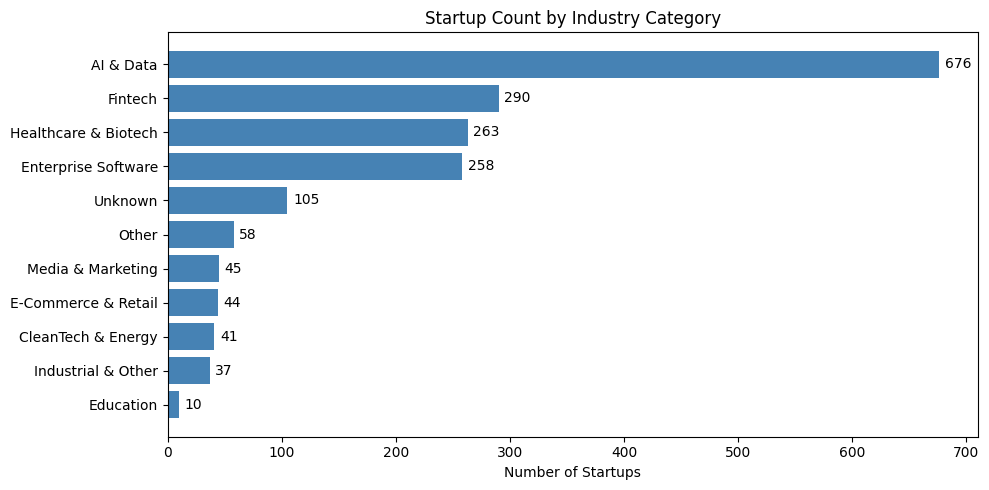

Industry_Category
AI & Data               676
Fintech                 290
Healthcare & Biotech    263
Enterprise Software     258
Unknown                 105
Other                    58
Media & Marketing        45
E-Commerce & Retail      44
CleanTech & Energy       41
Industrial & Other       37
Education                10
Name: count, dtype: int64


In [16]:
# Industry category distribution
industry_counts = df['Industry_Category'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(industry_counts.index, industry_counts.values, color='steelblue')
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_xlabel('Number of Startups')
ax.set_title('Startup Count by Industry Category')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(industry_counts)

### 3.3 Category Consolidation
Merge low-count and ambiguous industry categories to reduce noise before aggregation and export.

In [17]:
# Merge low-signal categories into 'Other/Unknown'
merge_cats = ['Unknown', 'Other', 'Education']
df['Industry_Category'] = df['Industry_Category'].replace(merge_cats, 'Other/Unknown')

# Confirm result
print(df['Industry_Category'].value_counts())
print("\nTotal rows:", len(df))

Industry_Category
AI & Data               676
Fintech                 290
Healthcare & Biotech    263
Enterprise Software     258
Other/Unknown           173
Media & Marketing        45
E-Commerce & Retail      44
CleanTech & Energy       41
Industrial & Other       37
Name: count, dtype: int64

Total rows: 1827


### 3.4 Funding Analysis by Industry
Aggregate total and median funding amounts by industry category to compare capital distribution across sectors.

In [18]:
# Funding summary by industry
funding_by_industry = df.groupby('Industry_Category').agg(
    Startup_Count=('Organization_Name', 'count'),
    Total_Funding_Sum=('Total_Funding_Amount', 'sum'),
    Total_Funding_Median=('Total_Funding_Amount', 'median'),
    Total_Funding_Mean=('Total_Funding_Amount', 'mean'),
    Avg_Funding_Rounds=('Number_of_Funding_Rounds', 'mean')
).reset_index()

# Round for readability
funding_by_industry = funding_by_industry.round(2)
funding_by_industry = funding_by_industry.sort_values('Total_Funding_Sum', ascending=False)

print(funding_by_industry.to_string(index=False))

   Industry_Category  Startup_Count  Total_Funding_Sum  Total_Funding_Median  Total_Funding_Mean  Avg_Funding_Rounds
           AI & Data            676       1.721605e+10             4690000.0         25467528.36                1.70
Healthcare & Biotech            263       9.874114e+09             6000000.0         37544160.94                1.51
             Fintech            290       8.289038e+09             4000000.0         28582888.80                1.59
  CleanTech & Energy             41       3.778480e+09            19900000.0         92158056.68                1.59
 Enterprise Software            258       3.499607e+09             3000000.0         13564368.69                1.51
       Other/Unknown            173       2.171579e+09             2700000.0         12552477.23                1.29
  Industrial & Other             37       1.526684e+09             6100000.0         41261729.19                1.59
   Media & Marketing             45       1.268952e+09          

### 3.5 Geographic Distribution
Analyze startup concentration by region to identify key startup hubs in the dataset.

In [19]:
# Startup count by region (using Region_Mid as primary geographic level)
geo_summary = df.groupby(['Region_Broad', 'Region_Mid']).agg(
    Startup_Count=('Organization_Name', 'count'),
    Total_Funding_Sum=('Total_Funding_Amount', 'sum'),
    Total_Funding_Median=('Total_Funding_Amount', 'median')
).reset_index()

geo_summary = geo_summary.sort_values('Startup_Count', ascending=False)
print(geo_summary.head(20).to_string(index=False))

   Region_Broad     Region_Mid  Startup_Count  Total_Funding_Sum  Total_Funding_Median
     Western US     West Coast            530       1.746441e+10             5000000.0
Northeastern US     East Coast            362       8.470225e+09             6000000.0
    Southern US     East Coast            206       5.707532e+09             2000000.0
        Unknown        Unknown            177       3.529215e+09             2999999.0
     Western US Silicon Valley            175       8.158989e+09             7000000.0
    Southern US        Unknown            167       2.306952e+09             1100000.0
     Western US        Unknown             80       7.438759e+08             3775000.0
  Midwestern US    Great Lakes             48       4.153872e+08             4525000.0
  Midwestern US        Unknown             47       2.333451e+08             2400000.0
Northeastern US    New England             15       4.168115e+08            10000000.0
Northeastern US        Unknown             

In [20]:
# Check what's inside West Coast vs Silicon Valley split
print(df[df['Region_Mid'] == 'West Coast']['Headquarters_Location'].value_counts().head(10))
print()
print(df[df['Region_Mid'] == 'Silicon Valley']['Headquarters_Location'].value_counts().head(10))

Headquarters_Location
San Francisco, California, United States          288
Los Angeles, California, United States             65
Seattle, Washington, United States                 35
San Diego, California, United States               13
Irvine, California, United States                  12
South San Francisco, California, United States      8
Santa Monica, California, United States             8
Berkeley, California, United States                 7
El Segundo, California, United States               5
Oakland, California, United States                  4
Name: count, dtype: int64

Headquarters_Location
Palo Alto, California, United States        61
Mountain View, California, United States    16
San Jose, California, United States         14
Santa Clara, California, United States      14
Menlo Park, California, United States       13
Sunnyvale, California, United States        12
San Mateo, California, United States        11
Redwood City, California, United States     10
Los Altos, Ca

### 3.6 Funding Trends Over Time
Aggregate funding activity by year and industry to identify how investment patterns have shifted across the dataset's time range.

In [21]:
# Extract founding year and last funding year
df['Founded_Year'] = df['Founded_Date'].dt.year
df['Last_Funding_Year'] = df['Last_Funding_Date'].dt.year

# Funding activity by last funding year
funding_by_year = df.groupby('Last_Funding_Year').agg(
    Deal_Count=('Organization_Name', 'count'),
    Total_Funding_Sum=('Total_Funding_Amount', 'sum'),
    Median_Funding=('Total_Funding_Amount', 'median')
).reset_index()

print(funding_by_year.to_string(index=False))

 Last_Funding_Year  Deal_Count  Total_Funding_Sum  Median_Funding
              2024         822       1.721395e+10       2512500.0
              2025        1005       3.077086e+10       6000000.0


In [22]:
# Funding by year and industry
funding_year_industry = df.groupby(['Last_Funding_Year', 'Industry_Category']).agg(
    Deal_Count=('Organization_Name', 'count'),
    Total_Funding_Sum=('Total_Funding_Amount', 'sum'),
    Median_Funding=('Total_Funding_Amount', 'median')
).reset_index()

print(funding_year_industry.to_string(index=False))

 Last_Funding_Year    Industry_Category  Deal_Count  Total_Funding_Sum  Median_Funding
              2024            AI & Data         281       3.763972e+09       3250000.0
              2024   CleanTech & Energy          19       1.177038e+09      12250000.0
              2024  E-Commerce & Retail          26       1.496168e+08        217500.0
              2024  Enterprise Software         123       1.542689e+09       1849999.0
              2024              Fintech         129       2.722958e+09       2400000.0
              2024 Healthcare & Biotech         119       4.719071e+09       2500000.0
              2024   Industrial & Other          18       1.101024e+09       6050000.0
              2024    Media & Marketing          23       1.185737e+09       3100000.0
              2024        Other/Unknown          84       8.518473e+08       1300000.0
              2025            AI & Data         395       1.345208e+10       6300000.0
              2025   CleanTech & Energy    

In [23]:
# Export all summary tables for Tableau
funding_by_industry.to_csv('tableau_funding_by_industry.csv', index=False)
geo_summary.to_csv('tableau_geo_summary.csv', index=False)
funding_by_year.to_csv('tableau_funding_by_year.csv', index=False)
funding_year_industry.to_csv('tableau_funding_year_industry.csv', index=False)

# Also export the full cleaned dataset for Tableau row-level filters
df.to_csv('tableau_startup_full.csv', index=False)

print("Exported:")
print("  tableau_funding_by_industry.csv")
print("  tableau_geo_summary.csv")
print("  tableau_funding_by_year.csv")
print("  tableau_funding_year_industry.csv")
print("  tableau_startup_full.csv")

Exported:
  tableau_funding_by_industry.csv
  tableau_geo_summary.csv
  tableau_funding_by_year.csv
  tableau_funding_year_industry.csv
  tableau_startup_full.csv


In [24]:
# Extract State from Headquarters_Location
df['State'] = df['Headquarters_Location'].str.split(', ').str[1]

# Verify
print(df['State'].value_counts().head(10))
print('Null count:', df['State'].isna().sum())

State
California       671
New York         271
Texas            116
Delaware         115
Florida          109
Massachusetts     75
Washington        49
Colorado          46
Illinois          37
Virginia          22
Name: count, dtype: int64
Null count: 0


In [27]:
# Check negative and zero funding amounts
print("Zero or negative Total_Funding_Amount:")
print(df[df['Total_Funding_Amount'] <= 0]['Total_Funding_Amount'].value_counts())
print("Count:", len(df[df['Total_Funding_Amount'] <= 0]))

# Filter out
df = df[df['Total_Funding_Amount'] > 0]
print("Rows after filtering:", len(df))

Zero or negative Total_Funding_Amount:
Series([], Name: count, dtype: int64)
Count: 0
Rows after filtering: 1576


In [31]:
print("Total rows:", len(df))
print("Zero values:", (df['Total_Funding_Amount'] == 0).sum())
print("NaN values:", df['Total_Funding_Amount'].isna().sum())
print("Negative values:", (df['Total_Funding_Amount'] < 0).sum())
print("Min value:", df['Total_Funding_Amount'].min())

Total rows: 1576
Zero values: 0
NaN values: 0
Negative values: 0
Min value: 1000.0


In [32]:
# Export updated CSV
df.to_csv('tableau_startup_full.csv', index=False)
print('Exported successfully, columns:', df.columns.tolist())

Exported successfully, columns: ['Organization_Name', 'Organization_Name_URL', 'Founded_Date', 'Founders', 'Number_of_Employees', 'Description', 'Industries', 'Industry_Groups', 'Headquarters_Location', 'Headquarters_Regions', 'Operating_Status', 'Funding_Status', 'Number_of_Funding_Rounds', 'Last_Funding_Amount', 'Last_Funding_Amount_Currency', 'Last_Funding_Date', 'Last_Funding_Type', 'Total_Funding_Amount', 'Total_Funding_Amount_Currency', 'Number_of_Lead_Investors', 'Top_5_Investors', 'Trend_Score_7_Days', 'Trend_Score_30_Days', 'Trend_Score_90_Days', 'Growth_Trend', 'Active_Hiring', 'Region_Local', 'Region_Mid', 'Region_Broad', 'Industry_Category', 'Founded_Year', 'Last_Funding_Year', 'State']


## Project Summary

### What This Project Does
End-to-end data analysis pipeline on 1,576 Crunchbase startups funded in 2024–2025.
Covers ETL, data cleaning, EDA, and Tableau dashboard.

### Data Challenges & Solutions
- **Type conversion**: Funding columns stored as strings → converted to float64;
  date columns stored as objects → converted to datetime64
- **Missing values**: 251 records had no funding amount → filtered out
- **Geographic data**: Raw location string ("San Francisco, California, United States")
  → extracted State column for Tableau mapping
- **Right-skewed distribution**: Funding data ranges from $1K to $3B with median $4M
  → used log scale in visualizations and median instead of mean for comparisons

### Key Findings
1. **AI & Data dominates by volume** (676 startups, $17.2B total) but median deal
   is only $4.7M —